In [1]:
import ee
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
import time

ee.Authenticate()
ee.Initialize(project='ee-wilhelmvan30')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("CUDA version:", torch.version.cuda)

Device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 5060 Ti
CUDA version: 12.8


In [2]:
jabodetabek_aoi = ee.Geometry.Polygon([
    [[106.30, -6.85],
   [107.40, -6.85],
   [107.40, -5.85], 
   [106.30, -5.85]]
])

In [3]:
# Sentinel 2020
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(jabodetabek_aoi)
      .filterDate('2020-01-01', '2020-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .median()
      .divide(10000))

# Spectral indices
ndvi = s2.normalizedDifference(['B8','B4']).rename('NDVI')
ndbi = s2.normalizedDifference(['B11','B8']).rename('NDBI')

stack = s2.select(['B2','B3','B4','B8','B11']) \
          .addBands(ndvi) \
          .addBands(ndbi)

# ESA WorldCover built-up
esa = ee.ImageCollection("ESA/WorldCover/v100").first()
built = esa.eq(50).rename("built")

final_image = stack.addBands(built).toFloat()


In [4]:
coords = jabodetabek_aoi.bounds().coordinates().getInfo()[0]

xmin = coords[0][0]
xmax = coords[2][0]
ymin = coords[2][1]
ymax = coords[0][1]

width = xmax - xmin

zone1 = ee.Geometry.Rectangle([xmin, ymin,
                               xmin + width/3, ymax])

zone2 = ee.Geometry.Rectangle([xmin + width/3, ymin,
                               xmin + 2*width/3, ymax])

zone3 = ee.Geometry.Rectangle([xmin + 2*width/3, ymin,
                               xmax, ymax])


In [5]:
def export_zone(image, region, name):
    task = ee.batch.Export.image.toDrive(
        image=image.clip(region),
        description=name,
        folder='GEE',
        fileNamePrefix=name,
        region=region,
        scale=10,
        maxPixels=1e13
    )
    task.start()
    print(name, "export started")

export_zone(final_image, zone1, "Jabodetabek_West")
export_zone(final_image, zone2, "Jabodetabek_Center")
export_zone(final_image, zone3, "Jabodetabek_East")


Jabodetabek_West export started
Jabodetabek_Center export started
Jabodetabek_East export started


In [6]:
import rasterio
import numpy as np

def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read()
    X = data[:-1]
    y = data[-1]
    X = np.transpose(X, (1,2,0))
    return X, y

X_train_area, y_train_area = load_raster("Jabodetabek_West.tif")
X_val_area, y_val_area     = load_raster("Jabodetabek_Center.tif")
X_test_area, y_test_area   = load_raster("Jabodetabek_East.tif")


In [7]:
def extract_patches_fraction(X, y, patch_size=128, n_samples=3000):

    H, W, C = X.shape
    patches = []
    labels = []

    for _ in range(n_samples):

        i = np.random.randint(0, H - patch_size)
        j = np.random.randint(0, W - patch_size)

        patch = X[i:i+patch_size, j:j+patch_size]
        mask_patch = y[i:i+patch_size, j:j+patch_size]

        label = np.mean(mask_patch)

        patches.append(patch)
        labels.append(label)

    patches = np.array(patches)
    labels = np.array(labels)

    patches = np.transpose(patches, (0,3,1,2))

    return patches, labels

X_train_p, y_train_p = extract_patches_fraction(X_train_area, y_train_area, 128, 3000)
X_val_p, y_val_p     = extract_patches_fraction(X_val_area, y_val_area, 128, 800)
X_test_p, y_test_p   = extract_patches_fraction(X_test_area, y_test_area, 128, 800)


In [8]:
means = X_train_p.mean(axis=(0,2,3))
stds  = X_train_p.std(axis=(0,2,3))

for c in range(7):
    X_train_p[:,c] = (X_train_p[:,c] - means[c]) / (stds[c] + 1e-6)
    X_val_p[:,c]   = (X_val_p[:,c]   - means[c]) / (stds[c] + 1e-6)
    X_test_p[:,c]  = (X_test_p[:,c]  - means[c]) / (stds[c] + 1e-6)


In [9]:
print("Train mean per channel:", X_train_p.mean(axis=(0,2,3)))
print("Train std per channel :", X_train_p.std(axis=(0,2,3)))


Train mean per channel: [ 0.37763765  0.47004005  0.36265007  0.48187068  0.49536243  0.21009104
 -0.1067951 ]
Train std per channel : [0.9040128  0.85647345 0.90447503 0.95641726 0.90296715 0.97484165
 0.9978975 ]


In [10]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]

        if pool:
            layers.append(nn.MaxPool2d(2))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CNNRegressor(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = ConvBlock(7, 32)
        self.layer2 = ConvBlock(32, 64)
        self.layer3 = ConvBlock(64, 128)
        self.layer4 = ConvBlock(128, 256, pool=False)

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.regressor(x)


In [11]:
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train_p, dtype=torch.float32)
X_val   = torch.tensor(X_val_p, dtype=torch.float32)
X_test  = torch.tensor(X_test_p, dtype=torch.float32)

y_train = torch.tensor(y_train_p, dtype=torch.float32)
y_val   = torch.tensor(y_val_p, dtype=torch.float32)
y_test  = torch.tensor(y_test_p, dtype=torch.float32)


In [12]:
train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=32, shuffle=True)

val_loader   = DataLoader(TensorDataset(X_val, y_val),
                          batch_size=32, shuffle=False)

test_loader  = DataLoader(TensorDataset(X_test, y_test),
                          batch_size=32, shuffle=False)


In [13]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNRegressor().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)


In [14]:
import copy

num_epochs = 200
patience = 20
min_delta = 1e-4

best_loss = float("inf")
counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss:   {val_loss:.6f}")
    print("-"*30)

    # ================= EARLY STOPPING =================
    if val_loss < best_loss - min_delta:
        best_loss = val_loss
        counter = 0
        best_weights = copy.deepcopy(model.state_dict())
        print("Best model updated")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

model.load_state_dict(best_weights)
print("Best model loaded.")


Epoch 1
Train Loss: 0.010180
Val Loss:   0.012076
------------------------------
Best model updated
Epoch 2
Train Loss: 0.004268
Val Loss:   0.014609
------------------------------
Epoch 3
Train Loss: 0.003687
Val Loss:   0.006856
------------------------------
Best model updated
Epoch 4
Train Loss: 0.003381
Val Loss:   0.006351
------------------------------
Best model updated
Epoch 5
Train Loss: 0.002603
Val Loss:   0.004481
------------------------------
Best model updated
Epoch 6
Train Loss: 0.002471
Val Loss:   0.002446
------------------------------
Best model updated
Epoch 7
Train Loss: 0.002352
Val Loss:   0.001576
------------------------------
Best model updated
Epoch 8
Train Loss: 0.002259
Val Loss:   0.005162
------------------------------
Epoch 9
Train Loss: 0.002223
Val Loss:   0.002592
------------------------------
Epoch 10
Train Loss: 0.001911
Val Loss:   0.005871
------------------------------
Epoch 11
Train Loss: 0.002220
Val Loss:   0.010070
------------------------

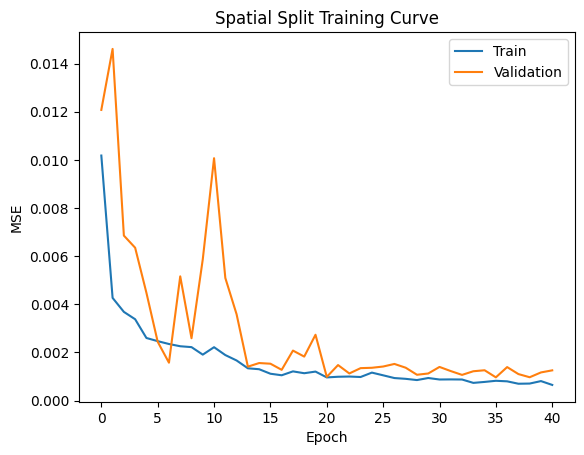

In [15]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.title("Spatial Split Training Curve")
plt.show()


In [16]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model.eval()

preds = []
truths = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        preds.append(outputs.cpu().numpy())
        truths.append(y_batch.numpy())

preds = np.concatenate(preds).flatten()
truths = np.concatenate(truths).flatten()

mse  = np.mean((preds - truths) ** 2)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(truths, preds)
r2   = r2_score(truths, preds)

print("Test MSE :", mse)
print("Test RMSE:", rmse)
print("Test MAE :", mae)
print("Test R²  :", r2)
print("Target range:", y_test_p.min(), "to", y_test_p.max())

Test MSE : 0.0009619049
Test RMSE: 0.031014591
Test MAE : 0.018873298540711403
Test R²  : 0.9627898335456848
Target range: 0.0 to 0.8256836


In [17]:
import numpy as np

truths = y_test.numpy()
baseline_mse = np.var(truths)

print("Baseline MSE:", baseline_mse)


Baseline MSE: 0.025850601


In [18]:
print("===== TRAIN =====")
print("Mean :", y_train.mean().item())
print("Std  :", y_train.std().item())
print("Var  :", y_train.var().item())

print("\n===== VALIDATION =====")
print("Mean :", y_val.mean().item())
print("Std  :", y_val.std().item())
print("Var  :", y_val.var().item())

print("\n===== TEST =====")
print("Mean :", y_test.mean().item())
print("Std  :", y_test.std().item())
print("Var  :", y_test.var().item())


===== TRAIN =====
Mean : 0.09519486129283905
Std  : 0.17696316540241241
Var  : 0.03131595999002457

===== VALIDATION =====
Mean : 0.2905556559562683
Std  : 0.3319244682788849
Var  : 0.11017385870218277

===== TEST =====
Mean : 0.09665794670581818
Std  : 0.16088178753852844
Var  : 0.02588295191526413


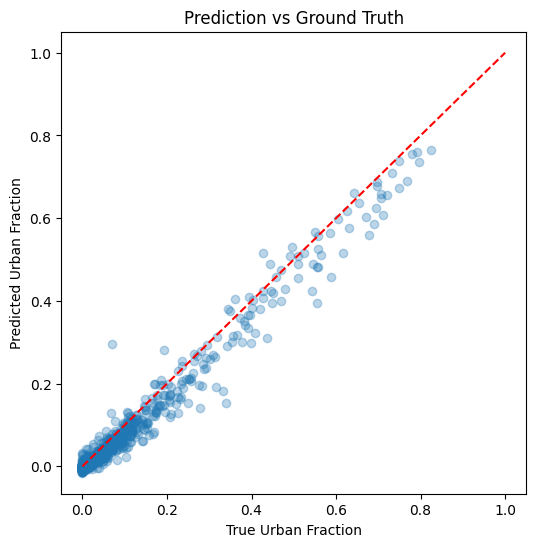

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(truths, preds, alpha=0.3)
plt.plot([0,1],[0,1], 'r--')
plt.xlabel("True Urban Fraction")
plt.ylabel("Predicted Urban Fraction")
plt.title("Prediction vs Ground Truth")
plt.show()


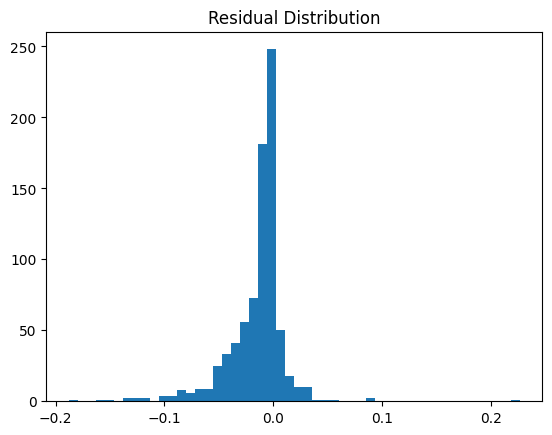

In [20]:
residuals = preds - truths

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()


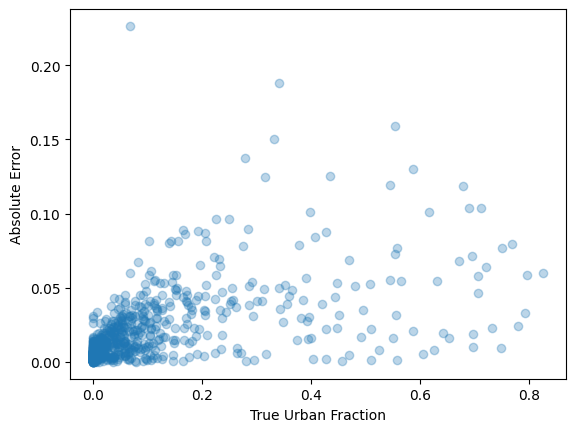

In [21]:
plt.scatter(truths, np.abs(residuals), alpha=0.3)
plt.xlabel("True Urban Fraction")
plt.ylabel("Absolute Error")
plt.show()